In [26]:
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

| Column | Description |
|--------|-------------|
| **Pig** | Unique animal ID (e.g., 4601) |
| **Evit** | Vitamin E treatment group (e.g., `Evit000` = no vitamin E) |
| **Cu** | Copper supplement treatment group (e.g., `Cu000` = no copper) |
| **Litter** | Litter number the pig came from |
| **Start** | Starting weight (kg) at the beginning of the study |
| **Weight** | Body weight (kg) at each time point |
| **Feed** | Cumulative feed consumed (kg) up to that time point |
| **Time** | Measurement occasion (week number or visit number) |


In [ ]:
df = sm.datasets.get_rdataset("dietox", "geepack").data
df.head(5)


,Pig,Evit,Cu,Litter,Start,Weight,Feed,Time
0,4601,Evit000,Cu000,1,26.5,26.50000,NaN,1
1,4601,Evit000,Cu000,1,26.5,27.59999,5.200005,2
2,4601,Evit000,Cu000,1,26.5,36.50000,17.600000,3
3,4601,Evit000,Cu000,1,26.5,40.29999,28.500000,4
4,4601,Evit000,Cu000,1,26.5,49.09998,45.200001,5


Fit a model to estimate the effect of time on weight with a random intercept for every pig.

`Time` coef. is 6.9 so each pig grows on average 6.9 kg a week. The CI is small so the estimate is precise. The group variance is large, justifying the random intercept. 

In [7]:
md = smf.mixedlm("Weight ~ Time", df, groups=df["Pig"])
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Weight    
No. Observations: 861     Method:             REML      
No. Groups:       72      Scale:              11.3669   
Min. group size:  11      Log-Likelihood:     -2404.7753
Max. group size:  12      Converged:          Yes       
Mean group size:  12.0                                  
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    15.724    0.788  19.952 0.000 14.179 17.268
Time          6.943    0.033 207.939 0.000  6.877  7.008
Group Var    40.395    2.149                            



Next, we specify a model with two random effects for every pig: intercept and the slope of time. Thus, each pig can start at a different weight and grow at a different rate. The `re_formula` defines the random effects structure (intercept is inculded automatically). 

In [17]:
md = smf.mixedlm("Weight ~ Time", df, groups=df["Pig"], re_formula="~Time")
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Weight    
No. Observations:  861      Method:              REML      
No. Groups:        72       Scale:               6.0372    
Min. group size:   11       Log-Likelihood:      -2217.0475
Max. group size:   12       Converged:           Yes       
Mean group size:   12.0                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        15.739    0.550 28.603 0.000 14.660 16.817
Time              6.939    0.080 86.925 0.000  6.783  7.095
Group Var        19.503    1.561                           
Group x Time Cov  0.294    0.153                           
Time Var          0.416    0.033                           



Calculate correlation `corr(X, Y) = cov(X, Y) / (SD(X) * SD(Y))` between random intercept and slope. They are only weakly correlated so pigs that start bigger do not systematically grow faster or slower.

In [14]:
0.294 / (19.503 * 0.416) ** 0.5

0.10321669639698673

We can contrain the random effects to be uncorrelated which means there is one parameter fewer (the covariance of the random slope and intercept) to estimate, making the model simpler.

`from_components` takes two arguments:

- **`np.ones(2)`** — a vector of 1s for the fixed effects (length 2 = intercept + Time slope), meaning both fixed effects are free to be estimated
- **`np.eye(2)`** — a 2x2 **identity matrix** for the random effects covariance structure
The off-diagonal zeros tell the optimizer: "do not estimate the covariance between the random intercept and random slope" — they are fixed at zero and not free parameters.  The diagonal ones mean both variances (Group Var and Time Var) are still freely estimated.

In [18]:
md = smf.mixedlm("Weight ~ Time", df, groups=df["Pig"], re_formula="~Time")
free = sm.regression.mixed_linear_model.MixedLMParams.from_components(
    np.ones(2), np.eye(2)
)

mdf = md.fit(free=free, method=["lbfgs"])
print(mdf.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Weight    
No. Observations:  861      Method:              REML      
No. Groups:        72       Scale:               6.0283    
Min. group size:   11       Log-Likelihood:      -2217.3481
Max. group size:   12       Converged:           Yes       
Mean group size:   12.0                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        15.739    0.554 28.388 0.000 14.652 16.825
Time              6.939    0.080 86.248 0.000  6.781  7.097
Group Var        19.837    1.571                           
Group x Time Cov  0.000    0.000                           
Time Var          0.423    0.033                           



To check if this made the model worse we compute the difference in log-likelihood times two. This follows a $\chi^2$ distribution under the null hypothesis. The distribution has 1 degree of freedom because we removed one parameter. The critical value for $\chi^2(1)$ at p = 0.05 is 3.84. Since 0.6 << 3.84, we fail to reject the null — the data are consistent with correlation = 0.



In [23]:
(-2217.0475 - (-2217.3481))*2

0.6012000000000626

Plotting fitted values agains residuals shows that there is heteroscedasticity: the model makes systematic errors on pigs with low weight.

Text(0, 0.5, 'Residuals')

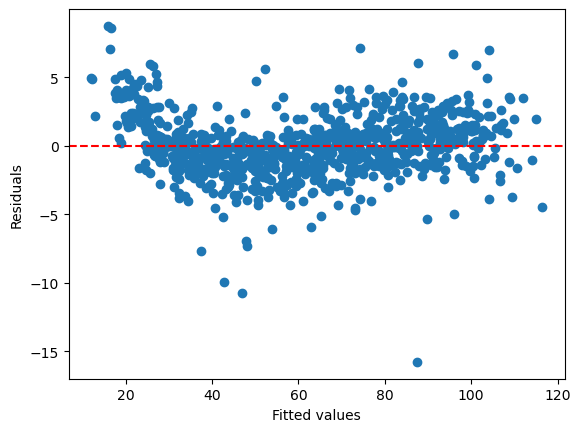

In [27]:
fig, ax = plt.subplots()
ax.scatter(mdf.fittedvalues, mdf.resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")


Try log transformation

In [30]:
df["logWeight"] = np.log(df["Weight"])
md = smf.mixedlm("logWeight ~ Time", df, groups=df["Pig"])
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logWeight
No. Observations: 861     Method:             REML     
No. Groups:       72      Scale:              0.0068   
Min. group size:  11      Log-Likelihood:     800.4736 
Max. group size:  12      Converged:          Yes      
Mean group size:  12.0                                 
-------------------------------------------------------
             Coef. Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    3.200    0.015 213.548 0.000  3.170  3.229
Time         0.125    0.001 152.809 0.000  0.124  0.127
Group Var    0.014    0.030                            



The heteroscedasticity is gone, but now there's a clear curved (arch) pattern — residuals are positive in the middle and negative at the extremes indicating nonlinearity

Text(0, 0.5, 'Residuals')

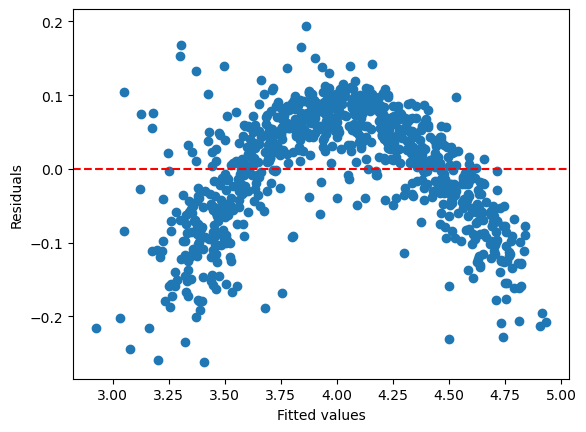

In [31]:
fig, ax = plt.subplots()
ax.scatter(mdf.fittedvalues, mdf.resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

Try a quadratic term

In [32]:
df["Time2"] = df["Time"] ** 2
md = smf.mixedlm("logWeight ~ Time + Time2", df, groups=df["Pig"])
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logWeight
No. Observations: 861     Method:             REML     
No. Groups:       72      Scale:              0.0032   
Min. group size:  11      Log-Likelihood:     1097.7885
Max. group size:  12      Converged:          Yes      
Mean group size:  12.0                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    3.033    0.015 195.761 0.000  3.003  3.063
Time         0.197    0.002  81.049 0.000  0.192  0.202
Time2       -0.006    0.000 -30.330 0.000 -0.006 -0.005
Group Var    0.014    0.044                            



Now the residuals are distributed much more evenly.

Text(0, 0.5, 'Residuals')

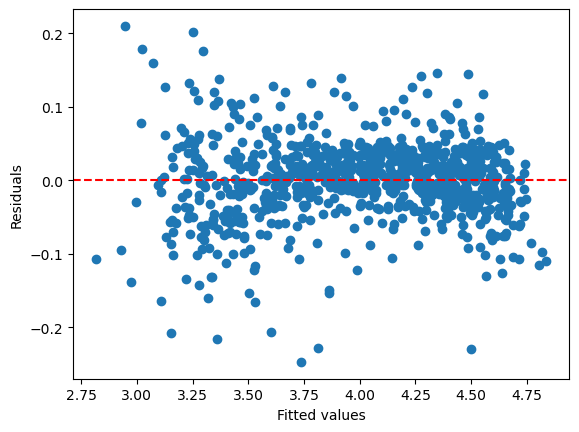

In [33]:
fig, ax = plt.subplots()
ax.scatter(mdf.fittedvalues, mdf.resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

Transform intercept from log back to original scale. For the intercept, we can just exponentiate but for time it's tricky because now weight depends on time and quadratic time:
 `log(Weight) = 3.033 + 0.197×Time - 0.006×Time²`

The instantaneous growth rate is given by the derivative w.r.t. time:
 `d(logWeight)/dTime = 0.197 - 2 × 0.006 × Time = 0.197 - 0.012 × Time`

So at each time point, weight is multiplied by approximately:
| Time | Rate | Interpretation |
|------|------|----------------|
| 1 | e^(0.197 - 0.012) = e^0.185 ≈ +20.3% | per week |
| 6 | e^(0.197 - 0.072) = e^0.125 ≈ +13.3% | per week |
| 12 | e^(0.197 - 0.144) = e^0.053 ≈ +5.4% | per week |

This makes sense because the growth slows down over time. Note that the quadratic term is just an approximation of the true sigmoidal growth curve.

In [35]:
np.exp(3.033)

np.float64(20.759417517911764)